**Salary** **prediction**


In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv('/content/Salary_Data.csv')

In [ ]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [ ]:
df.tail()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
6699,49.0,Female,PhD,Director of Marketing,20.0,200000.0
6700,32.0,Male,High School,Sales Associate,3.0,50000.0
6701,30.0,Female,Bachelor's Degree,Financial Manager,4.0,55000.0
6702,46.0,Male,Master's Degree,Marketing Manager,14.0,140000.0
6703,26.0,Female,High School,Sales Executive,1.0,35000.0


In [ ]:
df.isnull().sum()

,0
Age,2
Gender,2
Education Level,3
Job Title,2
Years of Experience,3
Salary,5


In [ ]:
df = df.dropna()
print(df)

       Age  Gender    Education Level              Job Title  \
0     32.0    Male         Bachelor's      Software Engineer   
1     28.0  Female           Master's           Data Analyst   
2     45.0    Male                PhD         Senior Manager   
3     36.0  Female         Bachelor's        Sales Associate   
4     52.0    Male           Master's               Director   
...    ...     ...                ...                    ...   
6699  49.0  Female                PhD  Director of Marketing   
6700  32.0    Male        High School        Sales Associate   
6701  30.0  Female  Bachelor's Degree      Financial Manager   
6702  46.0    Male    Master's Degree      Marketing Manager   
6703  26.0  Female        High School        Sales Executive   

      Years of Experience    Salary  
0                     5.0   90000.0  
1                     3.0   65000.0  
2                    15.0  150000.0  
3                     7.0   60000.0  
4                    20.0  200000.0  
...

In [ ]:
print(df.isnull().sum())

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64


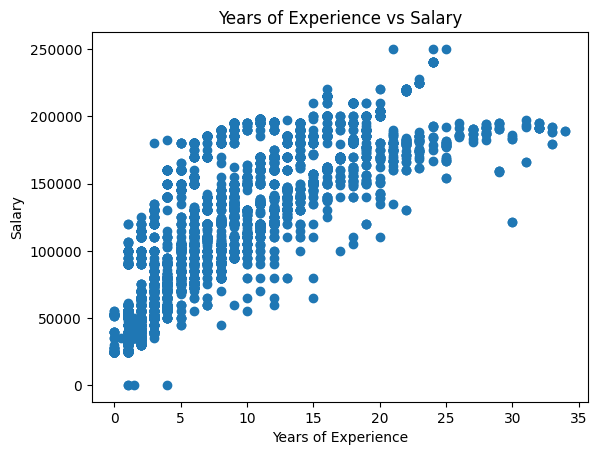

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df["Years of Experience"], df["Salary"])

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Years of Experience vs Salary")

plt.show()

Data Nature

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df[["Years of Experience"]]
y = df["Salary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
print("X_train:")
print(X_train)

print("X_test:")
print(X_test)

print("y_train:")
print(y_train)

print("y_test:")
print(y_test)

X_train:
      Years of Experience
3363                  5.0
990                  12.0
5701                  0.0
3020                  4.0
550                   3.0
...                   ...
907                   6.0
5196                  1.0
3984                  9.0
236                   9.0
5161                  0.0

[5358 rows x 1 columns]
X_test:
      Years of Experience
2191                 16.0
4373                 13.0
5632                  0.0
4978                  7.0
689                   9.0
...                   ...
5820                 14.0
2100                 17.0
2970                  9.0
883                   7.0
6439                  4.0

[1340 rows x 1 columns]
y_train:
3363     90000.0
990     190000.0
5701     25000.0
3020     92438.0
550     130000.0
          ...   
907     180000.0
5196     55000.0
3984    100000.0
236     100000.0
5161     25000.0
Name: Salary, Length: 5358, dtype: float64
y_test:
2191    185000.0
4373    131000.0
5632     40000.0
4978    120

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5358, 1)
(1340, 1)
(5358,)
(1340,)


In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
lr= LinearRegression()
lr.fit(X_train, y_train)  #model train

LinearRegression()

In [ ]:
print(lr.intercept_)

58428.57542599562


In [ ]:
print(lr.coef_)

[7067.75629549]


In [ ]:
print("Intercept:", lr.intercept_)
print("Coefficients:", lr.coef_)

Intercept: 58428.57542599562
Coefficients: [7067.75629549]


In [ ]:
y_pred = lr.predict(X_test)
print("Actual Salary:")
print(y_test)

print("Predicted Salary:")
print(y_pred)

Actual Salary:
2191    185000.0
4373    131000.0
5632     40000.0
4978    120000.0
689     195000.0
          ...   
5820    190000.0
2100    195000.0
2970    132638.0
883     185000.0
6439     55000.0
Name: Salary, Length: 1340, dtype: float64
Predicted Salary:
[171512.67615378 150309.40726732  58428.575426   ... 122038.38208538
 107902.8694944   86699.60060794]


In [ ]:
prediction = lr.predict([[2]])

print("Predicted Salary:", prediction[0])

Predicted Salary: 72564.0880169689


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


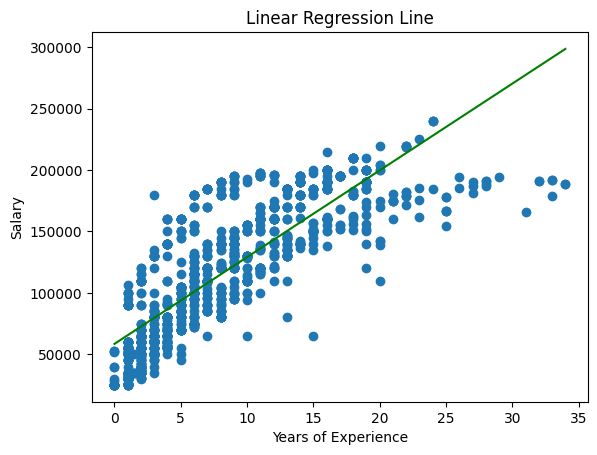

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X_sorted = X_test.sort_values(by="Years of Experience")
y_sorted_pred = lr.predict(X_sorted)

plt.scatter(X_test["Years of Experience"], y_test)
plt.plot(X_sorted["Years of Experience"], y_sorted_pred,color="green")

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Linear Regression Line")

plt.show()

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R² Score:", r2)
print("Accuracy:", r2 * 100, "%")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("Error:", mean_absolute_error(y_test, y_pred))

R² Score: 0.675589810053254
Accuracy: 67.5589810053254 %
MAE: 23888.992682211585
MSE: 906858195.9233402
RMSE: 30114.08633718347
Error: 23888.992682211585
